# Dataset Profiling & EDA - Inside Airbnb (Lisbon & Porto)
**Big Data Engineering - Master in Data Science and Engineering (MECD07)**

Datasets: `listings_clean.parquet` · `calendar_clean.parquet` · `reviews_clean.parquet`

In [1]:
!pip install pyspark -q

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Experimental Setup**

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession, functions as F
from matplotlib.patches import Patch

spark = (
    SparkSession.builder
    .appName("Airbnb_EDA")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.parquet.enableVectorizedReader", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

COLORS = {
    "LISBON": "#9B2C2C",
    "PORTO":  "#243B53"
}
#243B53
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

print("Spark:", spark.version)

Spark: 4.0.2











---



## **1 - Load Data**

We set the project paths and check the necessary files.

In [4]:
PROJECT_ROOT = Path("/content/drive/MyDrive/EGD_Project").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "clean"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Project exists:", PROJECT_ROOT.exists())
print("Data directory exists:", DATA_DIR.exists())

Project root: /content/drive/MyDrive/EGD_Project
Data directory: /content/drive/MyDrive/EGD_Project/data/clean
Project exists: True
Data directory exists: True


In [5]:
print("Files/folders inside data/clean:")

for item in DATA_DIR.iterdir():
    print("-", item.name)

for folder in [
    "listings_cleaned.parquet",
    "calendar_cleaned.parquet",
    "reviews_cleaned.parquet"
]:
    path = DATA_DIR / folder

    print("\n", folder)
    print("Exists:", path.exists())
    print("Is directory:", path.is_dir())

    if path.exists() and path.is_dir():
        print("Sample contents:", [p.name for p in list(path.iterdir())[:5]])

Files/folders inside data/clean:
- calendar_cleaned.parquet
- reviews_cleaned.parquet
- listings_cleaned.parquet

 listings_cleaned.parquet
Exists: True
Is directory: True
Sample contents: ['part-00000-96d7bda9-e12f-4eee-8bd9-e215b0c2d494-c000.snappy.parquet', '.part-00000-96d7bda9-e12f-4eee-8bd9-e215b0c2d494-c000.snappy.parquet.crc', '.part-00001-96d7bda9-e12f-4eee-8bd9-e215b0c2d494-c000.snappy.parquet.crc', 'part-00001-96d7bda9-e12f-4eee-8bd9-e215b0c2d494-c000.snappy.parquet', '._SUCCESS.crc']

 calendar_cleaned.parquet
Exists: True
Is directory: True
Sample contents: ['part-00000-6945d69c-5000-4b9c-b967-838a3673227c-c000.snappy.parquet', '.part-00001-6945d69c-5000-4b9c-b967-838a3673227c-c000.snappy.parquet.crc', 'part-00001-6945d69c-5000-4b9c-b967-838a3673227c-c000.snappy.parquet', '.part-00000-6945d69c-5000-4b9c-b967-838a3673227c-c000.snappy.parquet.crc', '.part-00002-6945d69c-5000-4b9c-b967-838a3673227c-c000.snappy.parquet.crc']

 reviews_cleaned.parquet
Exists: True
Is directory:

Now, we load the data.

In [6]:
paths = {
    "listings": DATA_DIR / "listings_cleaned.parquet",
    "calendar": DATA_DIR / "calendar_cleaned.parquet",
    "reviews": DATA_DIR / "reviews_cleaned.parquet",
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} -> {path}")
    if not path.exists():
        raise FileNotFoundError(f"{name} file not found at: {path}")

listings = spark.read.parquet(str(paths["listings"]))
calendar = spark.read.parquet(str(paths["calendar"]))
reviews = spark.read.parquet(str(paths["reviews"]))

listing_numeric_cols = [
    "price",
    "availability_365", "availability_30", "availability_60", "availability_90",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "calculated_host_listings_count",
    "bedrooms", "beds",
    "minimum_nights",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

for c in listing_numeric_cols:
    if c in listings.columns:
        listings = listings.withColumn(c, F.col(c).cast("double"))

calendar_numeric_cols = [
    "price",
    "adjusted_price",
    "minimum_nights",
    "maximum_nights"
]

for c in calendar_numeric_cols:
    if c in calendar.columns:
        calendar = calendar.withColumn(c, F.col(c).cast("double"))

print("Files loaded successfully.")
print("Listings:", listings.count())
print("Calendar:", calendar.count())
print("Reviews: ", reviews.count())

listings: True -> /content/drive/MyDrive/EGD_Project/data/clean/listings_cleaned.parquet
calendar: True -> /content/drive/MyDrive/EGD_Project/data/clean/calendar_cleaned.parquet
reviews: True -> /content/drive/MyDrive/EGD_Project/data/clean/reviews_cleaned.parquet
Files loaded successfully.
Listings: 34655
Calendar: 14408044
Reviews:  2690110






---



## **2 - Dataset Overview**

In [7]:
overview = pd.DataFrame({
    "Dataset":  ["listings", "calendar", "reviews"],
    "Rows":     [listings.count(), calendar.count(), reviews.count()],
    "Columns":  [len(listings.columns), len(calendar.columns), len(reviews.columns)],
})
print(overview.to_string(index=False))

 Dataset     Rows  Columns
listings    34655       80
calendar 14408044        8
 reviews  2690110        7


In [8]:
print("Records by city:")
for df, name in [(listings, "listings"), (calendar, "calendar"), (reviews, "reviews")]:
    print(f"\n{name}:")
    df.groupBy("city").count().show()

Records by city:

listings:
+------+-----+
|  city|count|
+------+-----+
|LISBON|21466|
| PORTO|13189|
+------+-----+


calendar:
+------+-------+
|  city|  count|
+------+-------+
|LISBON|8979368|
| PORTO|5428676|
+------+-------+


reviews:
+------+-------+
|  city|  count|
+------+-------+
|LISBON|1687411|
| PORTO|1002699|
+------+-------+



As observed, the dataset covers 34,655 listings: Lisbon accounts for 62% (21,466) while Porto  for the remaining 38% (13,189), consistent taking into account Lisbon has the larger tourism market. The calendar table is the largest at 14.4 M rows (one row per listing per day, June 2025 - July 2026). Reviews total 2.69 M, with Lisbon generating 63% (1.69 M) and Porto 37% (1.00 M).



---



## **3 - Missing Values Analysis**

In [9]:
total_rows = listings.count()
miss = []
for col in listings.columns:
    n = listings.filter(
        F.col(col).isNull() | (F.col(col).cast("string") == "")
    ).count()
    if n > 0:
        miss.append((col, n, round(100 * n / total_rows, 1)))

miss_df = (pd.DataFrame(miss, columns=["column", "missing", "pct_%"])
           .sort_values("pct_%", ascending=False))
print(miss_df.to_string(index=False))

                     column  missing  pct_%
           calendar_updated    34655  100.0
         host_neighbourhood    25683   74.1
      neighborhood_overview    15646   45.1
                 host_about    15622   45.1
              neighbourhood    15646   45.1
              host_location    10411   30.0
     review_scores_location     3934   11.4
               first_review     3929   11.3
     review_scores_accuracy     3933   11.3
        review_scores_value     3933   11.3
review_scores_communication     3933   11.3
       review_scores_rating     3929   11.3
          reviews_per_month     3929   11.3
      review_scores_checkin     3933   11.3
  review_scores_cleanliness     3933   11.3
                last_review     3929   11.3
          host_is_superhost     1795    5.2
                    license     1232    3.6
                description      853    2.5
           has_availability      325    0.9
                       beds       59    0.2
             bathrooms_text     

We can obtain from this analysis several insights: `calendar_updated` is 100% null and can be ignored. `host_neighbourhood` (74%) and `neighbourhood`/`neighborhood_overview` (45%) are highly incomplete but `neighbourhood_cleansed` is fully populated and used instead. Review-related scores are missing for 11% of listings - those that have never received a review. `host_is_superhost` is missing for 5.2%, and `license` for 3.6%. `calendar.price` is entirely null; price analysis uses the `listings.price` column exclusively.



---



## **4 - Listings Profiling**

###**4.1 - Listings by City**

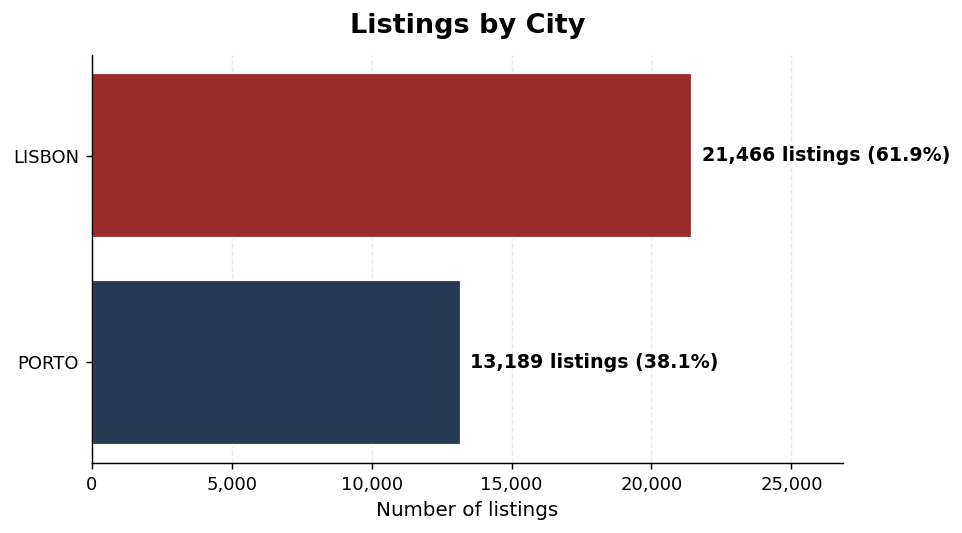

In [10]:
#Listings by city
city_count = (
    listings
    .groupBy("city")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)

city_count["percentage"] = city_count["count"] / city_count["count"].sum() * 100

#Keep city order from highest to lowest
city_count = city_count.sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(7.5, 4.2))

bars = ax.barh(
    city_count["city"],
    city_count["count"],
    color=[COLORS.get(city, "#808080") for city in city_count["city"]],
    edgecolor="white",
    linewidth=1.2
)

for bar, count, pct in zip(bars, city_count["count"], city_count["percentage"]):
    ax.text(
        bar.get_width() + city_count["count"].max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,.0f} listings ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=10.5,
        fontweight="bold"
    )

ax.set_title(
    "Listings by City",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Number of listings", fontsize=11)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.set_xlim(0, city_count["count"].max() * 1.25)

plt.tight_layout()

#Save figure
fig.savefig(FIGURES_DIR / "listings_by_city.png", dpi=300, bbox_inches="tight")

plt.show()

The listings dataset contains more records for Lisbon than for Porto. Lisbon represents approximately 62% of the combined listings, while Porto accounts for around 38%. As mentioned before, this indicates that the short-term market captured in the dataset is larger in Lisbon, which is expected given the city's larger tourism volume and metropolitan scale. This difference should be considered in later comparisons, since aggregate metrics may be influenced by the larger number of Lisbon listings.

### **4.2 - Room Type Distribution**

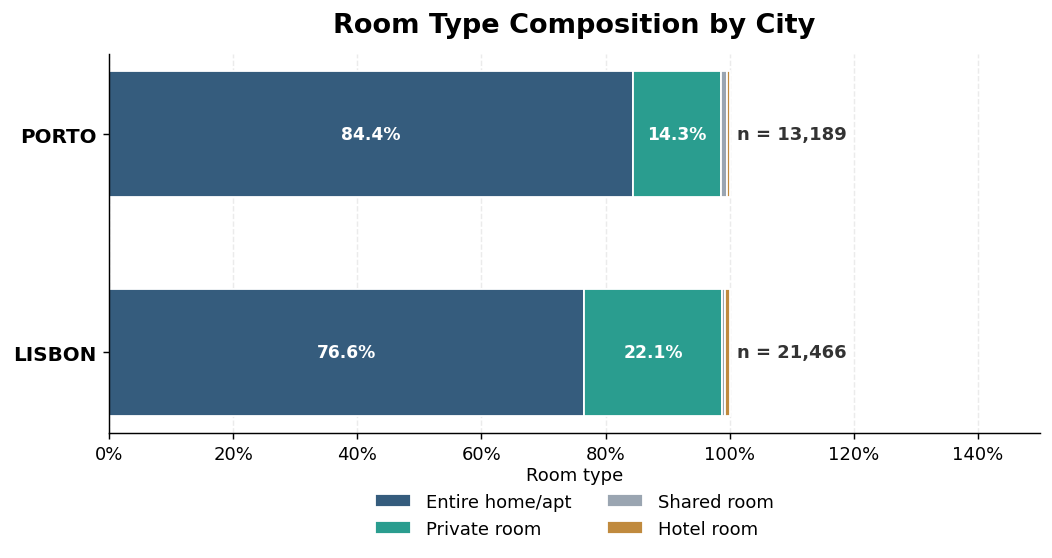


LISBON:
  Entire home/apt: 16,441 (76.6%)
  Private room: 4,747 (22.1%)
  Hotel room: 149 (0.7%)
  Shared room: 129 (0.6%)

PORTO:
  Entire home/apt: 11,135 (84.4%)
  Private room: 1,880 (14.3%)
  Shared room: 108 (0.8%)
  Hotel room: 66 (0.5%)


In [11]:
room_type_counts = (
    listings
    .groupBy("city", "room_type")
    .count()
)

#Total listings per city
city_totals = (
    room_type_counts
    .groupBy("city")
    .agg(F.sum("count").alias("city_total"))
)

#Add percentages
room_type_pct = (
    room_type_counts
    .join(city_totals, on="city", how="left")
    .withColumn("percentage", 100 * F.col("count") / F.col("city_total"))
)

room_type_pd = room_type_pct.toPandas()

#Order room types by overall frequency
room_order = (
    room_type_pd.groupby("room_type")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

city_order = ["LISBON", "PORTO"]

pivot_pct = (
    room_type_pd
    .pivot(index="city", columns="room_type", values="percentage")
    .fillna(0)
    .reindex(city_order)[room_order]
)

pivot_count = (
    room_type_pd
    .pivot(index="city", columns="room_type", values="count")
    .fillna(0)
    .reindex(city_order)[room_order]
)

ROOM_TYPE_COLORS = {
    "Entire home/apt": "#355C7D",   #navy
    "Private room":    "#2A9D8F",   #teal
    "Hotel room":      "#C08A3E",   #amber
    "Shared room":     "#9AA5B1"    #soft grey-blue
}

fig, ax = plt.subplots(figsize=(8.2, 4.6))

left = np.zeros(len(pivot_pct))
y_positions = np.arange(len(pivot_pct))

for room_type in room_order:
    values = pivot_pct[room_type].values
    bars = ax.barh(
        y_positions,
        values,
        left=left,
        height=0.58,
        color=ROOM_TYPE_COLORS.get(room_type, "#999999"),
        edgecolor="white",
        linewidth=1
    )

    #Percentage labels inside segments when large enough
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val >= 4:
            ax.text(
                left[i] + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9.5,
                color="white" if room_type in ["Entire home/apt", "Private room"] else "black",
                fontweight="bold"
            )

    left += values

#Total listings labels at the end of each bar
totals = pivot_count.sum(axis=1).values
for i, total in enumerate(totals):
    ax.text(
        101.2,
        i,
        f"n = {int(total):,}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(pivot_pct.index, fontsize=11, fontweight="bold")
ax.set_xlim(0, 150)
ax.set_ylabel("")
ax.set_title(
    "Room Type Composition by City",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=ROOM_TYPE_COLORS[rt], edgecolor="white", label=rt)
    for rt in room_order
]
ax.legend(
    handles=legend_handles,
    title="Room type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=2,
    frameon=False
)

#Save figure
plt.tight_layout()
fig.savefig(FIGURES_DIR / "room_type_composition_by_city.png", dpi=300, bbox_inches="tight")

plt.show()

#Percentages table
room_type_summary = (
    room_type_pd[["city", "room_type", "count", "percentage"]]
    .sort_values(["city", "count"], ascending=[True, False])
)

for city in city_order:
    city_rows = room_type_summary[room_type_summary["city"] == city]

    print(f"\n{city}:")
    for _, row in city_rows.iterrows():
        print(
            f"  {row['room_type']}: {int(row['count']):,} "
            f"({row['percentage']:.1f}%)"
        )

As observed in the graph, the distribution of room types is clearly dominated by entire homes/apartments in both cities. However, Porto shows a higher concentration in this category, where it takes up to the 84.4% of the listings, compared with 76.6% in Lisbon. In contrast, Lisbon has a relatively larger share of private rooms (22.1% versus 14.3% in Porto), indicating a more diversified accommodation structure. Hotel rooms and shared rooms represent only a tiny proportion of the market in both cities.

### **4.3 - Top Neighbourhoods**

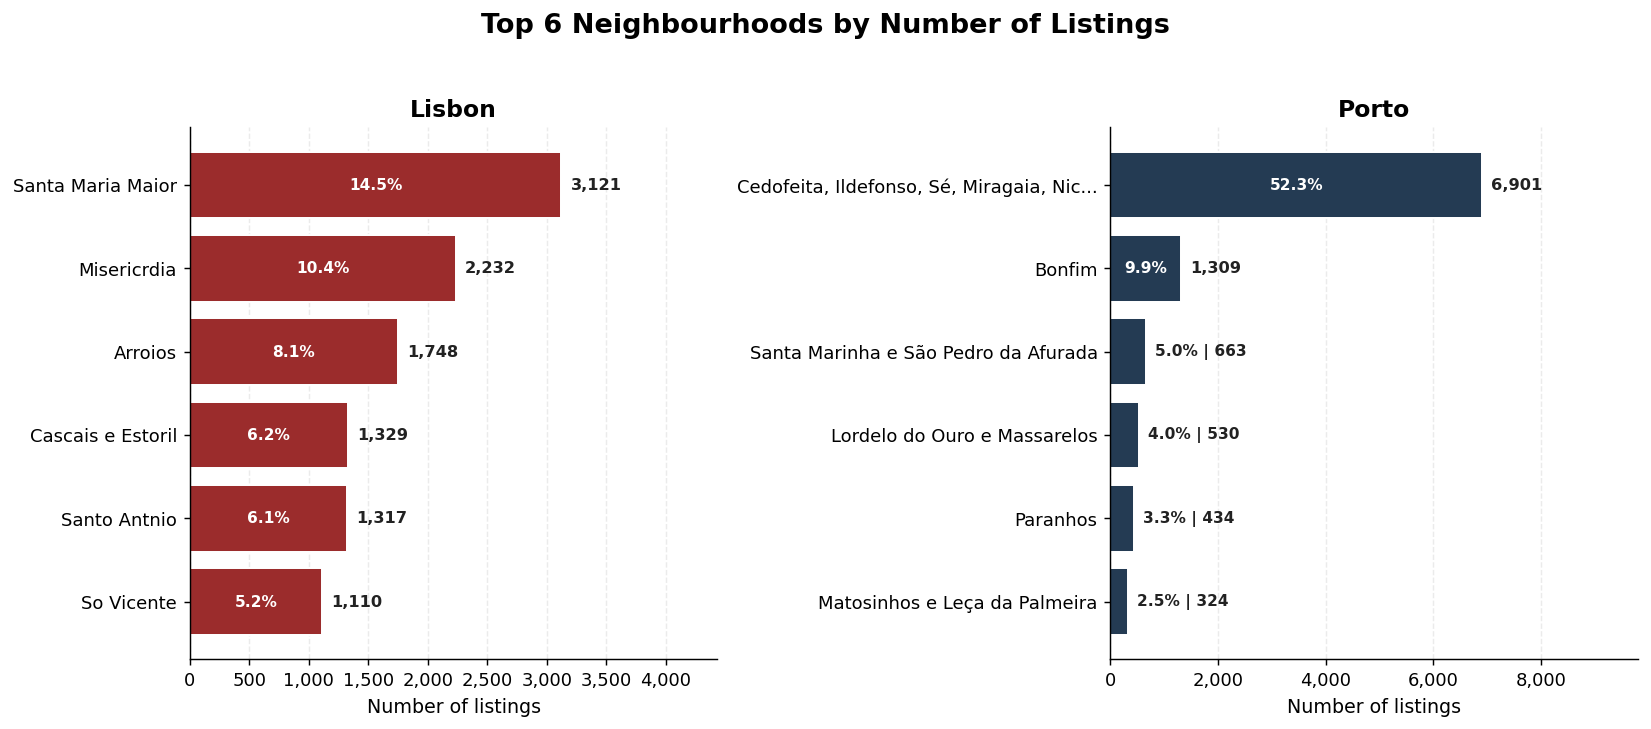

In [12]:
neighbourhood_counts = (
    listings
    .groupBy("city", "neighbourhood_cleansed")
    .count()
)

city_totals = (
    neighbourhood_counts
    .groupBy("city")
    .agg(F.sum("count").alias("city_total"))
)

neighbourhood_share = (
    neighbourhood_counts
    .join(city_totals, on="city", how="left")
    .withColumn("share", 100 * F.col("count") / F.col("city_total"))
)

neigh_pd = neighbourhood_share.toPandas()

top_n = 6

#Selecting top N neighbourhoods within each city
top_neigh_pd = (
    neigh_pd
    .sort_values(["city", "count"], ascending=[True, False])
    .groupby("city")
    .head(top_n)
    .copy()
)

def shorten_label(label, max_len=42):
    label = str(label)
    if len(label) <= max_len:
        return label
    return label[:max_len - 3] + "..."

top_neigh_pd["neighbourhood_short"] = top_neigh_pd["neighbourhood_cleansed"].apply(shorten_label)

top_neigh_pd = top_neigh_pd.sort_values(["city", "count"], ascending=[True, True])

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.8, 5.4),
    sharex=False
)

for ax, city in zip(axes, ["LISBON", "PORTO"]):
    city_data = top_neigh_pd[top_neigh_pd["city"] == city].copy()

    bars = ax.barh(
        city_data["neighbourhood_short"],
        city_data["count"],
        color=COLORS.get(city, "#808080"),
        edgecolor="white",
        linewidth=1.1
    )

    max_count = city_data["count"].max()

    for bar, count, share in zip(bars, city_data["count"], city_data["share"]):
        width = bar.get_width()


        if width >= max_count * 0.18:
            ax.text(
                width * 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{share:.1f}%",
                va="center",
                ha="center",
                fontsize=8.5,
                fontweight="bold",
                color="white"
            )


            ax.text(
                width + max_count * 0.025,
                bar.get_y() + bar.get_height() / 2,
                f"{int(count):,}",
                va="center",
                ha="left",
                fontsize=9,
                fontweight="bold",
                color="#222222"
            )

        else:
            ax.text(
                width + max_count * 0.025,
                bar.get_y() + bar.get_height() / 2,
                f"{share:.1f}% | {int(count):,}",
                va="center",
                ha="left",
                fontsize=8.5,
                fontweight="bold",
                color="#222222"
            )

    ax.set_title(city.title(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of listings", fontsize=10.5)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlim(0, max_count * 1.42)

fig.suptitle(
    f"Top {top_n} Neighbourhoods by Number of Listings",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "top_neighbourhoods_by_city_with_percentages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Airbnb listings are concentrated around the central and touristics neighbourhoods of each city.In Lisbon, we can appreciate a more distributed pattern, with Santa Maria Maior, Misericordia and Arroios leading the ranking. Meanwhile, we can see in Porto a much robust concentration, with Cedofeita, Ildelfonso, Sé, ..., representing a significant share of the city's listings. This implies Porto's Airbnb market heavily revolves around its historic center, while Lisbon's one spreads across a wider range of high-demand areas all around the city.

### **4.4 - Accommodates Distribution**

In [13]:
acc = (listings.groupBy("accommodates").count()
       .orderBy("accommodates")).toPandas()
print(acc.to_string(index=False))

 accommodates  count
          1.0   1383
          2.0  12294
          3.0   3282
          4.0   9505
          5.0   1683
          6.0   3697
          7.0    424
          8.0   1088
          9.0    223
         10.0    485
         11.0     55
         12.0    171
         13.0     37
         14.0     85
         15.0     34
         16.0    209


The distribution of `accommodates` shows that most listings are designed for small groups. Properties for 2 guests are the most common, followed by listings for 4 guests, indicating that the market is mainly oriented towards couples, solo travellers and small families. Larger listings exist but are much less frequent, especially above 8 guests, suggesting that large-group accommodation is a smaller niche in the Airbnb supply.

shows that listings are mostly designed for smaller groups. Properties for 2 guests are the most common (12294), followed by 4 guests (9505). This indicates the market is heavily oriented towards couples and small families. Larger listings are less frequent, observing a great decrease above 8 guests, suggesting that this niche is still developing in the Airbnb supply.

### **4.5 - Host Type: Single vs Multi-listing**

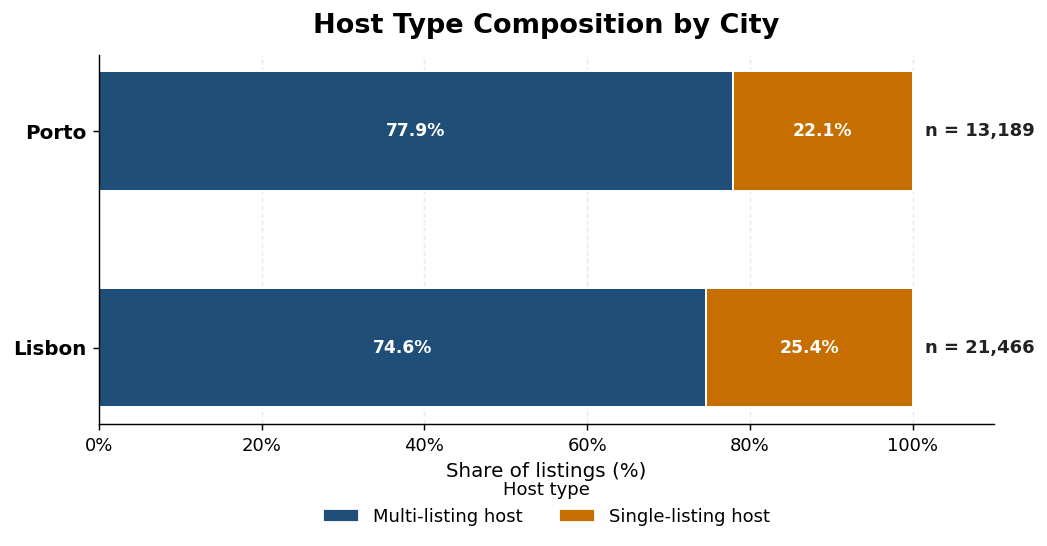

,city,host_type,count,percentage
2,LISBON,Multi-listing host,16009,74.6
0,LISBON,Single-listing host,5457,25.4
1,PORTO,Multi-listing host,10271,77.9
3,PORTO,Single-listing host,2918,22.1


In [14]:
host_type_counts = (
    listings
    .withColumn(
        "host_type",
        F.when(F.col("calculated_host_listings_count") > 1, "Multi-listing host")
         .otherwise("Single-listing host")
    )
    .groupBy("city", "host_type")
    .count()
)

#City totals and percentages
host_city_totals = (
    host_type_counts
    .groupBy("city")
    .agg(F.sum("count").alias("city_total"))
)

host_type_share = (
    host_type_counts
    .join(host_city_totals, on="city", how="left")
    .withColumn("percentage", 100 * F.col("count") / F.col("city_total"))
)

host_pd = host_type_share.toPandas()

city_order = ["LISBON", "PORTO"]
host_order = ["Multi-listing host", "Single-listing host"]

pivot_pct = (
    host_pd
    .pivot(index="city", columns="host_type", values="percentage")
    .fillna(0)
    .reindex(city_order)[host_order]
)

pivot_count = (
    host_pd
    .pivot(index="city", columns="host_type", values="count")
    .fillna(0)
    .reindex(city_order)[host_order]
)

HOST_TYPE_COLORS = {
    "Multi-listing host": "#1F4E79",
    "Single-listing host": "#C76E00"
}

fig, ax = plt.subplots(figsize=(8.2, 4.5))

left = np.zeros(len(pivot_pct))
y_positions = np.arange(len(pivot_pct))

for host_type in host_order:
    values = pivot_pct[host_type].values

    bars = ax.barh(
        y_positions,
        values,
        left=left,
        height=0.55,
        color=HOST_TYPE_COLORS[host_type],
        edgecolor="white",
        linewidth=1.1
    )

    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(
            left[i] + val / 2,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="white"
        )

    left += values

#Adding listing count
totals = pivot_count.sum(axis=1).values

for i, total in enumerate(totals):
    ax.text(
        101.5,
        i,
        f"n = {int(total):,}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

ax.set_yticks(y_positions)
ax.set_yticklabels([city.title() for city in pivot_pct.index], fontsize=11, fontweight="bold")

ax.set_xlim(0, 110)
ax.set_xlabel("Share of listings (%)", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Host Type Composition by City",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=HOST_TYPE_COLORS[h], edgecolor="white", label=h)
    for h in host_order
]

ax.legend(
    handles=legend_handles,
    title="Host type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=2,
    frameon=False
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "host_type_composition_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Summary table
host_summary = (
    host_pd[["city", "host_type", "count", "percentage"]]
    .sort_values(["city", "count"], ascending=[True, False])
    .copy()
)

host_summary["percentage"] = host_summary["percentage"].round(1)
host_summary

As observed in the host type distribution graph, most listings in both cities are operated by multi-listing hosts. In Lisbon, multi-listing hosts take up to the 74.6% of listings, while Porto has a slightly bigger share, around 77.9%. This suggests that the Airbnb supply in both cities is strongly professionalized, with a large proportion of properties managed by hosts operating more than one listing. Single-listing hosts represent a smaller part of the market, especially in Porto.

This analysis is quite relevant, as host types may influence pricing strategies, availability and listing quality.


### **4.6 - Availability (365 Days)**

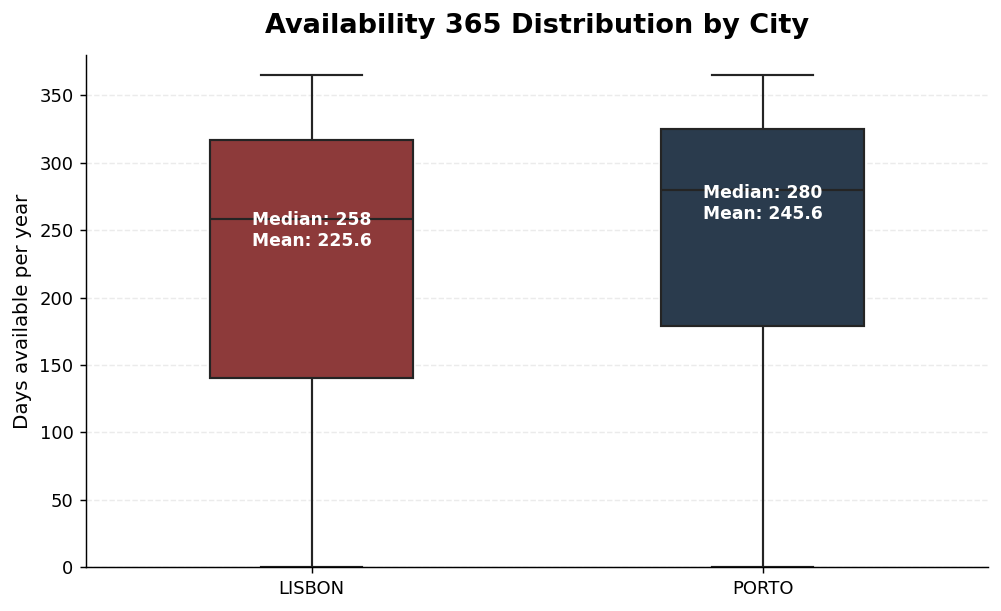

,city,mean_availability,median_availability,q1,q3
0,LISBON,225.6,258.0,140.0,317.0
1,PORTO,245.6,280.0,179.0,325.0


In [15]:
availability_pd = (
    listings
    .select("city", "availability_365")
    .filter(F.col("availability_365").isNotNull())
    .toPandas()
)

city_order = ["LISBON", "PORTO"]

availability_stats = (
    listings
    .groupBy("city")
    .agg(
        F.round(F.avg("availability_365"), 1).alias("mean_availability"),
        F.round(F.expr("percentile_approx(availability_365, 0.5)"), 1).alias("median_availability"),
        F.round(F.expr("percentile_approx(availability_365, 0.25)"), 1).alias("q1"),
        F.round(F.expr("percentile_approx(availability_365, 0.75)"), 1).alias("q3")
    )
    .toPandas()
)

fig, ax = plt.subplots(figsize=(7.8, 4.8))

sns.boxplot(
    data=availability_pd,
    x="city",
    y="availability_365",
    order=city_order,
    palette=COLORS,
    width=0.45,
    linewidth=1.2,
    fliersize=2.5,
    ax=ax
)

for i, city in enumerate(city_order):
    row = availability_stats[availability_stats["city"] == city].iloc[0]

    q1 = row["q1"]
    q3 = row["q3"]
    median_value = row["median_availability"]
    mean_value = row["mean_availability"]

    text_y = q1 + 0.62 * (q3 - q1)

    ax.text(
        i,
        text_y,
        f"Median: {median_value:.0f}\nMean: {mean_value:.1f}",
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color="white"
    )

ax.set_title(
    "Availability 365 Distribution by City",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Days available per year", fontsize=11)
ax.set_ylim(0, 380)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "availability_365_boxplot_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

availability_stats

The availability distribution shows that listings in both cities tend to be available for a large part of the year, with many properties concentrated above 250 available days. Porto presents slightly higher availability than Lisbon, with an average of 245.6 days and a median of 280 days, compared with Lisbon's average of 225.6 days and median of 258 days. This suggests that Porto listings are, on average, available for more days per year. The pattern may indicate a stronger presence of full-time or highly available short-term rentals, while lower availability values may correspond to more occasionally rented properties or listings with higher occupancy.

### **4.7 - Review Score Rating**

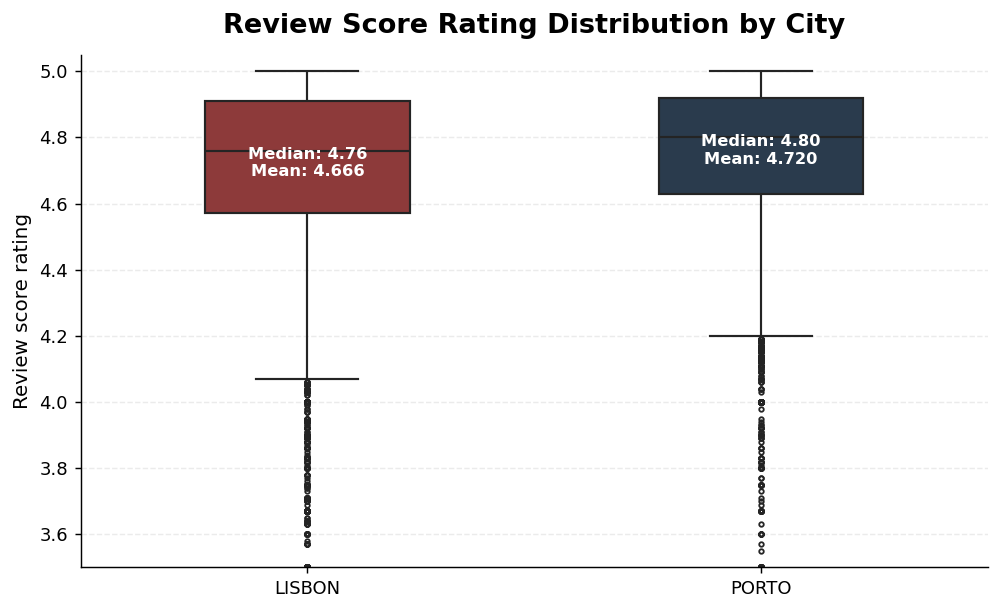

,city,mean_rating,median_rating,q1,q3,rated_listings
0,LISBON,4.666,4.76,4.57,4.91,18838
1,PORTO,4.720,4.80,4.63,4.92,11888


In [16]:
rating_pd = (
    listings
    .select("city", "review_scores_rating")
    .filter(F.col("review_scores_rating").isNotNull())
    .toPandas()
)

city_order = ["LISBON", "PORTO"]

rating_stats = (
    listings
    .filter(F.col("review_scores_rating").isNotNull())
    .groupBy("city")
    .agg(
        F.round(F.avg("review_scores_rating"), 3).alias("mean_rating"),
        F.round(F.expr("percentile_approx(review_scores_rating, 0.5)"), 2).alias("median_rating"),
        F.round(F.expr("percentile_approx(review_scores_rating, 0.25)"), 2).alias("q1"),
        F.round(F.expr("percentile_approx(review_scores_rating, 0.75)"), 2).alias("q3"),
        F.count("*").alias("rated_listings")
    )
    .toPandas()
)

fig, ax = plt.subplots(figsize=(7.8, 4.8))

sns.boxplot( data=rating_pd, x="city",y="review_scores_rating",
    order=city_order,
    palette=COLORS,
    width=0.45,
    linewidth=1.2,
    fliersize=2.5,
    ax=ax
)

for i, city in enumerate(city_order):
    row = rating_stats[rating_stats["city"] == city].iloc[0]

    q1 = row["q1"]
    q3 = row["q3"]
    mean_rating = row["mean_rating"]
    median_rating = row["median_rating"]

    text_y = q1 + 0.45 * (q3 - q1)

    ax.text(
        i,
        text_y,
        f"Median: {median_rating:.2f}\nMean: {mean_rating:.3f}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

ax.set_title(
    "Review Score Rating Distribution by City",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Review score rating", fontsize=11)
ax.set_ylim(3.5, 5.05)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "review_score_rating_boxplot_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

rating_stats.sort_values("city")

The review score distribution is concentrated nearing the upper end of the rating scale in both cities. Porto has a slightly higher median rating (4.80) than Lisbon (4.76), as well as a higher mean rating (4.720 - 4.666). This implies that Porto listings receive marginally better guest evaluations on average. Nevertheless, the difference is quite small, and both cities show high review scores, with the presence of some uncommon low-rating outliers with indicate that some listings perform significantly below the typical market level.



---



## **5 - Price Profiling**
Price is taken from `listings.price` (fully populated). Calendar price is entirely null. We cap at €2,000 to exclude non-representative luxury outliers while keeping the analysis honest.

### **5.1 - Summary Statistics by City**

In [17]:
price_stats = (listings
    .filter((F.col("price") > 0) & (F.col("price") < 2000))
    .groupBy("city")
    .agg(
        F.count("*").alias("n"),
        F.round(F.avg("price"), 2).alias("avg"),
        F.round(F.expr("percentile_approx(price, 0.5)"), 2).alias("median"),
        F.round(F.min("price"), 2).alias("min"),
        F.round(F.max("price"), 2).alias("max"),
        F.round(F.stddev("price"), 2).alias("std"),
    )
).toPandas()
print(price_stats.to_string(index=False))

  city     n    avg  median  min    max    std
LISBON 21279 143.92   109.0 10.0 1980.0 141.79
 PORTO 13123 114.27    90.0 10.0 1900.0  97.61


### **5.2 - Price Distribution by City**

For visualization purposes, this plot only includes listings with prices below €500 per night. The original prices were not modified or removed from the dataset; higher-price listings are analyzed separately in the outlier detection section.

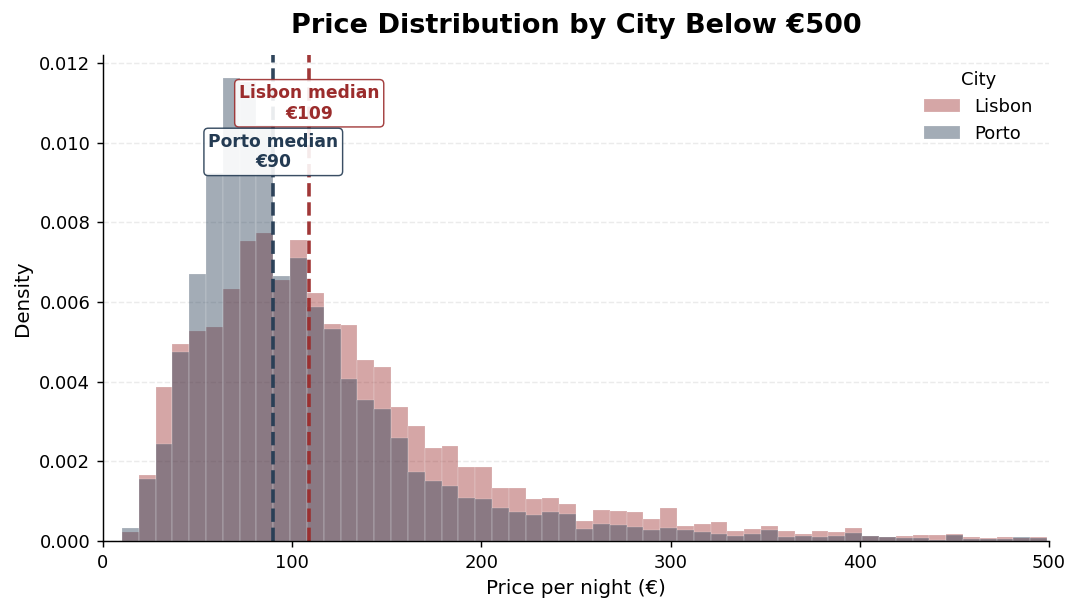

,city,median_price,mean_price
0,LISBON,109.0,238.10
1,PORTO,90.0,176.91


In [18]:
price_plot_limit = 500

price_pd = (
    listings
    .select("city", "price")
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("price") > 0) &
        (F.col("price") < price_plot_limit)
    )
    .toPandas()
)

#Median and mean prices
price_stats = (
    listings
    .filter((F.col("price").isNotNull()) & (F.col("price") > 0))
    .groupBy("city")
    .agg(
        F.round(F.expr("percentile_approx(price, 0.5)"), 2).alias("median_price"),
        F.round(F.avg("price"), 2).alias("mean_price")
    )
    .toPandas()
)

fig, ax = plt.subplots(figsize=(8.4, 4.8))

for city, city_data in price_pd.groupby("city"):
    ax.hist(
        city_data["price"],
        bins=55,
        density=True,
        alpha=0.42,
        color=COLORS.get(city, "#808080"),
        label=city.title(),
        edgecolor="white",
        linewidth=0.25
    )

#Median lines and labels
ymax = ax.get_ylim()[1]

for idx, row in price_stats.sort_values("city").iterrows():
    city = row["city"]
    median_value = row["median_price"]
    color = COLORS.get(city, "#808080")

    ax.axvline(
        median_value,
        color=color,
        linestyle="--",
        linewidth=2,
        alpha=0.95
    )

    ax.text(
        median_value,
        ymax * (0.94 if city == "LISBON" else 0.84),
        f"{city.title()} median\n€{median_value:.0f}",
        color=color,
        fontsize=9.5,
        fontweight="bold",
        ha="center",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=color,
            linewidth=0.8,
            alpha=0.9
        )
    )

ax.set_title(
    "Price Distribution by City Below €500",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Price per night (€)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.set_xlim(0, price_plot_limit)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(title="City", frameon=False, loc="upper right")

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "price_distribution_by_city_below_500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
display(price_stats.sort_values("city"))


The price distribution is right-skewed in both cities, with most listings concentrated below €200 per night. Lisbon's distribution is shifted towards higher prices compared with Porto, as shown by its higher median price. Porto has a stronger concentration in lower price ranges, while Lisbon shows a longer upper tail within the plotted range. This suggests that Lisbon has a higher typical price level.

###**5.3 - Price Outlier Detection**

In [19]:
#5.3.1 Price Quantiles by City

valid_prices = listings.filter(
    F.col("price").isNotNull() & (F.col("price") > 0)
)

price_quantiles = (
    valid_prices
    .groupBy("city")
    .agg(
        F.expr(
            "percentile_approx(price, array(0.25, 0.5, 0.75, 0.90, 0.95, 0.99))"
        ).alias("quantiles")
    )
    .orderBy("city")
)

price_quantiles_pd = price_quantiles.toPandas()

quantile_columns = ["q25", "median_q50", "q75", "q90", "q95", "q99"]

price_quantiles_table = pd.concat(
    [
        price_quantiles_pd[["city"]].reset_index(drop=True),
        pd.DataFrame(
            price_quantiles_pd["quantiles"].tolist(),
            columns=quantile_columns
        )
    ],
    axis=1
)

for col in quantile_columns:
    price_quantiles_table[col] = price_quantiles_table[col].round(2)

display(price_quantiles_table)

,city,q25,median_q50,q75,q90,q95,q99
0,LISBON,75.0,109.0,165.0,268.0,389.0,1450.0
1,PORTO,66.0,90.0,130.0,197.0,275.0,639.0


In [20]:
#5.3.2 High-Price Listings by City
thresholds = [500, 1000, 2000]

city_price_totals = (
    valid_prices
    .groupBy("city")
    .count()
    .withColumnRenamed("count", "city_total")
)

outlier_dfs = []

for threshold in thresholds:
    threshold_df = (
        valid_prices
        .filter(F.col("price") > threshold)
        .groupBy("city")
        .count()
        .withColumnRenamed("count", "outlier_count")
        .withColumn("threshold", F.lit(threshold))
    )

    outlier_dfs.append(threshold_df)

price_outliers = outlier_dfs[0]

for df in outlier_dfs[1:]:
    price_outliers = price_outliers.unionByName(df)

price_outliers = (
    price_outliers
    .join(city_price_totals, on="city", how="left")
    .withColumn(
        "percentage_of_city",
        F.round(100 * F.col("outlier_count") / F.col("city_total"), 2)
    )
    .select(
        "city",
        "threshold",
        "outlier_count",
        "city_total",
        "percentage_of_city"
    )
    .orderBy("threshold", "city")
)

price_outliers_table = price_outliers.toPandas()

display(price_outliers_table)

,city,threshold,outlier_count,city_total,percentage_of_city
0,LISBON,500,711,21466,3.31
1,PORTO,500,195,13189,1.48
2,LISBON,1000,287,21466,1.34
3,PORTO,1000,82,13189,0.62
4,LISBON,2000,178,21466,0.83
5,PORTO,2000,66,13189,0.50


In [21]:
#5.3.3 Global High-Price Outlier Summary

global_total = valid_prices.count()

global_outlier_rows = []

for threshold in thresholds:
    outlier_count = valid_prices.filter(F.col("price") > threshold).count()
    percentage = round(100 * outlier_count / global_total, 2)

    global_outlier_rows.append({
        "threshold": threshold,
        "outlier_count": outlier_count,
        "total_valid_listings": global_total,
        "percentage": percentage
    })

global_outliers_table = pd.DataFrame(global_outlier_rows)

display(global_outliers_table)

,threshold,outlier_count,total_valid_listings,percentage
0,500,906,34655,2.61
1,1000,369,34655,1.06
2,2000,244,34655,0.70


The price outlier analysis confirms that listing prices are strongly right-skewed in both cities. Lisbon has higher prices across the distribution, with a median price of €165 compared with €130 in Porto. The difference becomes especially large in the upper tail: Lisbon reaches €1,450 at the 99th percentile, while Porto reaches €639. This suggests that Lisbon has both a higher typical price level and a more pronounced high-end segment.

The outliers were kept in the dataset, but filtered versions are used in some plots to improve readability.

### **5.4 - Price by Room Type**

,city,room_type,avg_price,median_price,n
0,LISBON,Hotel room,257.43,156.0,125
1,LISBON,Entire home/apt,164.59,125.0,16280
2,LISBON,Private room,72.64,53.0,4745
3,LISBON,Shared room,47.63,31.0,129
4,PORTO,Hotel room,223.34,176.0,58
5,PORTO,Entire home/apt,121.38,95.0,11084
6,PORTO,Private room,73.77,56.0,1873
7,PORTO,Shared room,27.79,25.0,108


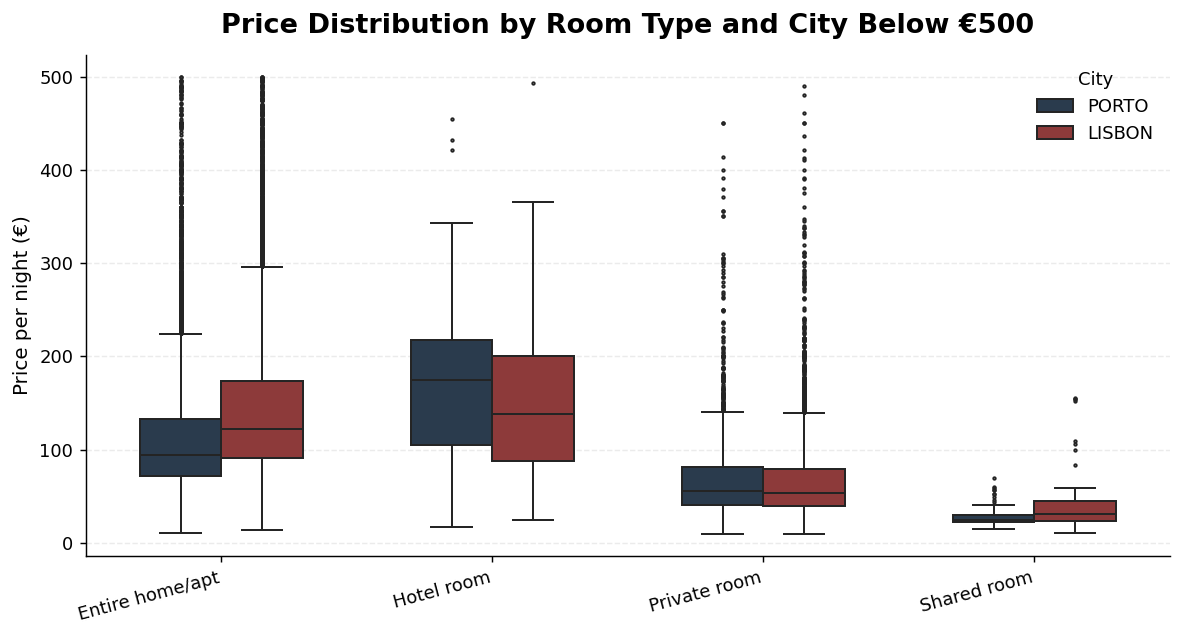

In [22]:
price_plot_limit = 500

room_type_order = [
    "Entire home/apt",
    "Hotel room",
    "Private room",
    "Shared room"
]

#Summary statistics by city and room type
price_room = (
    listings
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("price") > 0) &
        (F.col("price") < 2000)
    )
    .groupBy("city", "room_type")
    .agg(
        F.round(F.avg("price"), 2).alias("avg_price"),
        F.round(F.expr("percentile_approx(price, 0.5)"), 2).alias("median_price"),
        F.count("*").alias("n")
    )
    .orderBy("city", F.desc("median_price"))
    .toPandas()
)

display(price_room)

#Filter extreme values for readability
price_room_pd = (
    listings
    .select("city", "room_type", "price")
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("price") > 0) &
        (F.col("price") < price_plot_limit) &
        (F.col("room_type").isin(room_type_order))
    )
    .toPandas()
)

fig, ax = plt.subplots(figsize=(9.2, 5))

sns.boxplot(
    data=price_room_pd,
    x="room_type",
    y="price",
    hue="city",
    order=room_type_order,
    palette=COLORS,
    width=0.6,
    linewidth=1.1,
    fliersize=1.4,
    ax=ax
)

ax.set_title(
    "Price Distribution by Room Type and City Below €500",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Price per night (€)", fontsize=11)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=15,
    ha="right"
)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(
    title="City",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "price_by_room_type_city_below_500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The boxplot shows that price varies by room type. Entire homes/apartments and hotel rooms tend to have the highest prices, while private rooms and shared rooms are clearly cheaper. Lisbon generally presents higher prices than Porto for comparable room types, especially for entire homes/apartments and hotel rooms. This confirms that both city and room type are important factors for explaining price differences.

*Hotel room results should be interpreted carefully because the number of observations is much smaller than for entire homes/apartments and private rooms.

### **5.5 - Price by Neighbourhood (Top 10)**

In [23]:
price_neigh = (listings
    .filter((F.col("price") > 0) & (F.col("price") < 2000))
    .groupBy("city", "neighbourhood_cleansed")
    .agg(F.round(F.avg("price"), 2).alias("avg_price"),
         F.count("*").alias("n"))
    .filter(F.col("n") >= 30)
    .orderBy("avg_price", ascending=False)
).toPandas()

for city in ["LISBON", "PORTO"]:
    print(f"\nTop 10 most expensive neighbourhoods - {city}:")
    print(price_neigh[price_neigh["city"]==city].head(10).to_string(index=False))


Top 10 most expensive neighbourhoods - LISBON:
  city                            neighbourhood_cleansed  avg_price    n
LISBON                                           Ribamar     285.31   35
LISBON                                           Colares     256.13  418
LISBON                                      Santa Brbara     215.63   30
LISBON                                       Alcabideche     211.88  155
LISBON                                 Cascais e Estoril     196.61 1311
LISBON      Almargem do Bispo, Pro Pinheiro e Montelavar     175.58   31
LISBON                                             Mafra     174.12   57
LISBON S.Maria, S.Miguel, S.Martinho, S.Pedro Penaferrim     171.35  574
LISBON                                          Encarnao     163.34   47
LISBON                                   Parque das Naes     163.28  290

Top 10 most expensive neighbourhoods - PORTO:
 city                neighbourhood_cleansed  avg_price   n
PORTO                              Canidelo



---



## **6 - Calendar Profiling**

### **6.1 - Overview and Date Range**

In [24]:
calendar_date_range = (
    calendar
    .agg(
        F.min("date").alias("start_date"),
        F.max("date").alias("end_date")
    )
)

calendar_date_range = calendar_date_range.toPandas()
display(calendar_date_range)

#Calendar availability overview by city
calendar_overview = (
    calendar
    .groupBy("city")
    .agg(
        F.count("*").alias("total_calendar_rows"),
        F.countDistinct("listing_id").alias("unique_listings"),
        F.sum(F.when(F.col("available") == "t", 1).otherwise(0)).alias("available_days"),
        F.sum(F.when(F.col("available") == "f", 1).otherwise(0)).alias("blocked_days"),
        F.round(
            100 * F.sum(F.when(F.col("available") == "t", 1).otherwise(0)) / F.count("*"),
            2
        ).alias("availability_rate_pct"),
        F.round(F.avg("price"), 2).alias("avg_calendar_price")
    )
    .orderBy("city")
)

calendar_overview_table = calendar_overview.toPandas()

display(calendar_overview_table)

,start_date,end_date
0,2025-06-25,2026-07-01


,city,total_calendar_rows,unique_listings,available_days,blocked_days,availability_rate_pct,avg_calendar_price
0,LISBON,8979368,24601,5096432,3882936,56.76,NaN
1,PORTO,5428676,14873,3327318,2101358,61.29,NaN


### **6.2 - Monthly Availability Rate**

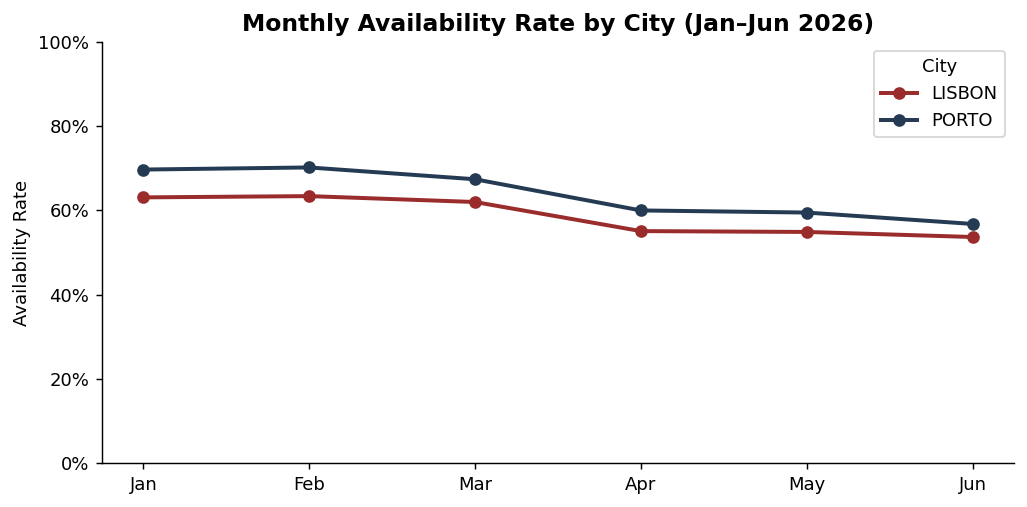

  city  month  avail_rate
LISBON      1       0.631
LISBON      2       0.634
LISBON      3       0.620
LISBON      4       0.551
LISBON      5       0.549
LISBON      6       0.537
 PORTO      1       0.697
 PORTO      2       0.702
 PORTO      3       0.674
 PORTO      4       0.600
 PORTO      5       0.595
 PORTO      6       0.568


In [35]:
cal_month = (calendar
    .withColumn("year",  F.year("date"))
    .withColumn("month", F.month("date"))
    .groupBy("city", "year", "month")
    .agg(F.count("*").alias("total"),
         F.sum(F.when(F.col("available") == "t", 1).otherwise(0)).alias("avail"))
    .withColumn("avail_rate", F.round(F.col("avail") / F.col("total"), 3))
    .orderBy("city", "year", "month")
).toPandas()

#Plot 2026 only
cal26 = cal_month[(cal_month["year"] == 2026) & (cal_month["month"] <= 6)].copy()
month_labels = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

fig, ax = plt.subplots(figsize=(8, 4))
for city, grp in cal26.groupby("city"):
    ax.plot(grp["month"], grp["avail_rate"], marker="o",
            linewidth=2.2, color=COLORS[city], label=city)

ax.set_xticks(range(1, 7))
ax.set_xticklabels([month_labels[m] for m in range(1, 7)])

ax.set_title("Monthly Availability Rate by City (Jan–Jun 2026)", fontsize=13, fontweight="bold")
ax.set_ylabel("Availability Rate"); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(title="City")
plt.tight_layout(); plt.show()

fig.savefig(
    FIGURES_DIR / "monthly_available_rate_by_city_2023_2025.png",
    dpi=300,
    bbox_inches="tight"
)

print(cal26[["city","month","avail_rate"]].to_string(index=False))

Overall availability is 57% in Lisbon and 61% in Porto (Jun 2025-Jul 2026). For 2026, both cities show declining availability from February (Lisbon 63%, Porto 70%) through June (Lisbon 54%, Porto 57%), indicating increasing booking pressure as the summer season approaches. Porto is consistently 5-10 percentage points more available than Lisbon throughout, suggesting a less saturated or higher-supply market.



---



## **7 - Reviews Profiling**

### **7.1 - Overview**

This section profiles the reviews dataset. Reviews are useful as an indirect indicator of guest activity and demand, although they should not be interpreted as exact bookings because not every guest leaves a review.

In [26]:
reviews_overview = (
    reviews
    .groupBy("city")
    .agg(
        F.count("*").alias("total_reviews"),
        F.countDistinct("listing_id").alias("reviewed_listings"),
        F.countDistinct("reviewer_id").alias("unique_reviewers"),
        F.min("date").alias("first_review"),
        F.max("date").alias("last_review")
    )
    .orderBy("city")
)

reviews_overview_table = reviews_overview.toPandas()

display(reviews_overview_table)

,city,total_reviews,reviewed_listings,unique_reviewers,first_review,last_review
0,LISBON,1687411,21263,1522744,2010-07-24,2025-07-02
1,PORTO,1002699,13219,938120,2011-05-10,2025-06-28


### **7.2 - Monthly Review Trend (Demand Proxy)**

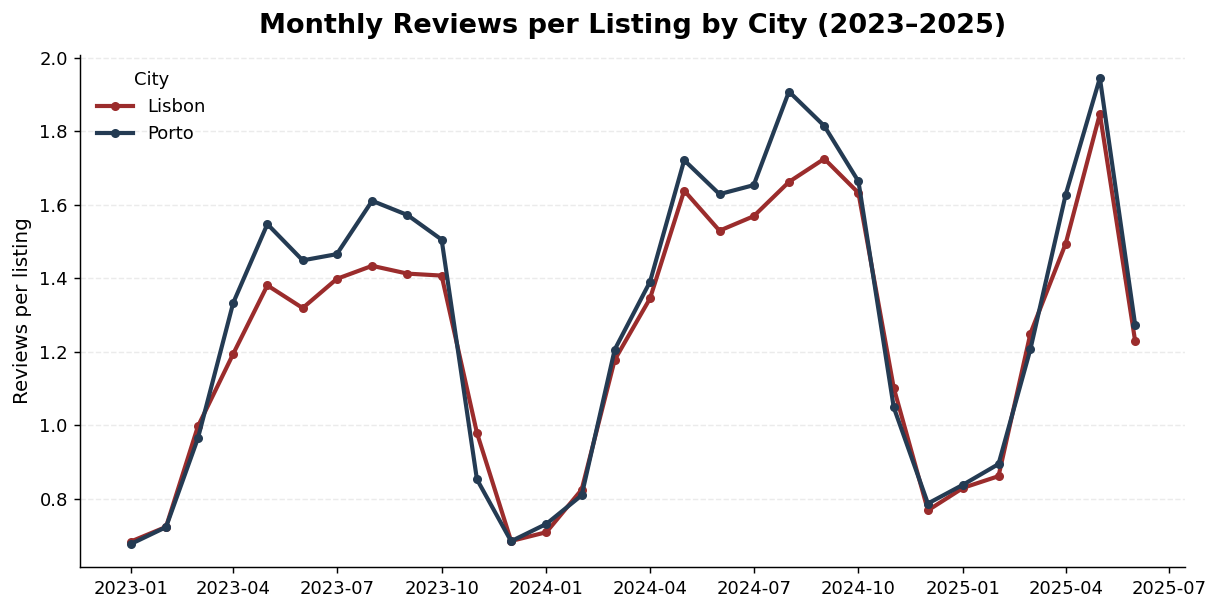

In [27]:
listings_by_city = (
    listings
    .groupBy("city")
    .agg(F.countDistinct("id").alias("total_listings"))
)
monthly_reviews = (
    reviews
    .withColumn("month", F.date_trunc("month", F.col("date")))
    .groupBy("city", "month")
    .agg(F.count("*").alias("review_count"))
    .orderBy("city", "month")
)

monthly_reviews_normalized = (
    monthly_reviews
    .join(listings_by_city, on="city", how="left")
    .withColumn(
        "reviews_per_listing",
        F.col("review_count") / F.col("total_listings")
    )
    .orderBy("city", "month")
)

monthly_reviews_norm_pd = monthly_reviews_normalized.toPandas()
monthly_reviews_norm_pd["month"] = pd.to_datetime(monthly_reviews_norm_pd["month"])

monthly_reviews_norm_pd = monthly_reviews_norm_pd[
    monthly_reviews_norm_pd["month"].between("2023-01-01", "2025-06-01")
].copy()

fig, ax = plt.subplots(figsize=(9.5, 4.8))

for city, city_data in monthly_reviews_norm_pd.groupby("city"):
    city_data = city_data.sort_values("month")

    ax.plot(
        city_data["month"],
        city_data["reviews_per_listing"],
        linewidth=2.3,
        marker="o",
        markersize=4,
        color=COLORS.get(city, "#808080"),
        label=city.title()
    )

ax.set_title(
    "Monthly Reviews per Listing by City (2023–2025)",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Reviews per listing", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(
    title="City",
    frameon=False,
    loc="upper left"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "monthly_reviews_per_listing_by_city_2023_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The monthly review count shows a clear seasonal trend in both cities. Review activity tends to increase during spring and summer months and decreases during winter periods, which is consistent with tourism seasonality. Lisbon has a higher absolute number of reviews throughout the period, which is expected because it also has a larger number of listings. Both cities show similar temporal patterns, suggesting that demand and tourist dynamics are aligned across Lisbon and Porto.

When review counts are normalized by the number of listings, the comparison becomes less affected by the larger size of the Lisbon market. This helps evaluate review activity intensity rather than only total volume. Reviews are still only an indirect proxy for demand, since not every stay results in a review and review volume can be affected by listing age, guest behavior and platform dynamics.



---



## **8. Geographic Analysis**

In [28]:
try:
    import folium

    geo_pd = (listings
        .select("latitude", "longitude", "city", "room_type", "neighbourhood_cleansed", "price")
        .filter(F.col("latitude").isNotNull() & F.col("longitude").isNotNull())
        .sample(fraction=0.05, seed=42)
    ).toPandas()

    city_colors = {"LISBON": "red", "PORTO": "blue"}
    m = folium.Map(location=[39.7, -8.3], zoom_start=7, tiles="CartoDB positron")

    for _, row in geo_pd.iterrows():
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=3,
            color=city_colors.get(row["city"], "gray"),
            fill=True, fill_opacity=0.6,
            popup=f"{row['neighbourhood_cleansed']} | {row['room_type']} | €{row['price']}"
        ).add_to(m)

    m.save("airbnb_map.html")
    print(f"Map saved — {len(geo_pd)} points plotted.")
except ImportError:
    print("Run: pip install folium")

Map saved — 1834 points plotted.


As mentioned before, listings concentrate heavily in historic city centres: in Porto along the Ribeira/Cedofeita corridor, while in Lisbon around Baixa, Alfama, and Bairro Alto. Lisbon's footprint extends further, reaching the Cascais/Estoril coast, Sintra, and Ericeira. This reflects a broader metropolitan scope compared to Porto's more compact urban cluster.



---



## **9. Summary Tables**

In [29]:
#Table 1 - Dataset Overview
def dataset_city_summary(df, dataset_name):
    total_rows = df.count()
    total_cols = len(df.columns)

    city_counts = (
        df.groupBy("city")
        .count()
        .toPandas()
    )

    summary = {
        "Dataset": dataset_name,
        "Rows": total_rows,
        "Columns": total_cols
    }

    for _, row in city_counts.iterrows():
        city = row["city"].title()
        count = int(row["count"])
        pct = 100 * count / total_rows
        summary[city] = f"{count:,} ({pct:.1f}%)"

    return summary


dataset_overview = pd.DataFrame([
    dataset_city_summary(listings, "listings"),
    dataset_city_summary(calendar, "calendar"),
    dataset_city_summary(reviews, "reviews")
])

dataset_overview["Rows"] = dataset_overview["Rows"].apply(lambda x: f"{x:,}")

display(dataset_overview)

,Dataset,Rows,Columns,Lisbon,Porto
0,listings,"34,655",80,"21,466 (61.9%)","13,189 (38.1%)"
1,calendar,"14,408,044",8,"8,979,368 (62.3%)","5,428,676 (37.7%)"
2,reviews,"2,690,110",7,"1,687,411 (62.7%)","1,002,699 (37.3%)"


In [30]:
#Table 2 - Key Missing Values
key_missing_values = pd.DataFrame({
    "Column": [
        "calendar_updated",
        "host_neighbourhood",
        "neighbourhood",
        "host_about",
        "host_location",
        "review_scores_*",
        "host_is_superhost",
        "calendar.price"
    ],
    "Missing (%)": [
        100,
        74,
        45,
        45,
        30,
        11,
        5,
        100
    ],
    "Impact": [
        "Ignored — never populated",
        "No impact — neighbourhood_cleansed used",
        "No impact — neighbourhood_cleansed used",
        "Low — optional text field",
        "Low — optional field",
        "Moderate — listings with no reviews excluded",
        "Moderate — superhost comparison limited",
        "Critical — calendar price analysis not possible"
    ]
})

display(key_missing_values)

,Column,Missing (%),Impact
0,calendar_updated,100,Ignored — never populated
1,host_neighbourhood,74,No impact — neighbourhood_cleansed used
2,neighbourhood,45,No impact — neighbourhood_cleansed used
3,host_about,45,Low — optional text field
4,host_location,30,Low — optional field
5,review_scores_*,11,Moderate — listings with no reviews excluded
6,host_is_superhost,5,Moderate — superhost comparison limited
7,calendar.price,100,Critical — calendar price analysis not possible


In [31]:
# Table 3 - City-level Listing Statistics

city_stats = (
    listings
    .groupBy("city")
    .agg(
        F.count("*").alias("total_listings"),
        F.round(F.avg("accommodates"), 2).alias("avg_accommodates"),
        F.round(F.avg("availability_365"), 1).alias("avg_availability_365"),
        F.round(F.avg("review_scores_rating"), 3).alias("avg_rating"),
        F.round(F.avg("number_of_reviews"), 1).alias("avg_number_of_reviews")
    )
    .orderBy("city")
)

city_stats_table = city_stats.toPandas()
city_stats_table["total_listings"] = city_stats_table["total_listings"].apply(lambda x: f"{x:,}")

display(city_stats_table)

,city,total_listings,avg_accommodates,avg_availability_365,avg_rating,avg_number_of_reviews
0,LISBON,"21,466",3.85,225.6,4.666,73.8
1,PORTO,"13,189",3.68,245.6,4.720,72.0


In [32]:
#Table 4 - Price Summary by City
valid_prices = (
    listings
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("price") > 0) &
        (F.col("price") < 2000)
    )
)

price_summary = (
    valid_prices
    .groupBy("city")
    .agg(
        F.count("*").alias("n"),
        F.round(F.avg("price"), 2).alias("avg_price"),
        F.round(F.expr("percentile_approx(price, 0.5)"), 2).alias("median_price"),
        F.round(F.stddev("price"), 2).alias("std_price"),
        F.round(F.expr("percentile_approx(price, 0.75)"), 2).alias("p75"),
        F.round(F.expr("percentile_approx(price, 0.95)"), 2).alias("p95"),
        F.round(F.expr("percentile_approx(price, 0.99)"), 2).alias("p99")
    )
    .orderBy("city")
)

price_summary_table = price_summary.toPandas()
price_summary_table["n"] = price_summary_table["n"].apply(lambda x: f"{x:,}")

for col in ["avg_price", "median_price", "std_price", "p75", "p95", "p99"]:
    price_summary_table[col] = price_summary_table[col].apply(lambda x: f"€{x:,.2f}")

price_summary_table = price_summary_table.rename(columns={
    "city": "City",
    "n": "n",
    "avg_price": "Avg.",
    "median_price": "Median",
    "std_price": "Std.",
    "p75": "P75",
    "p95": "P95",
    "p99": "P99"
})

display(price_summary_table)

,City,n,Avg.,Median,Std.,P75,P95,P99
0,LISBON,"21,279",€143.92,€109.00,€141.79,€162.00,€350.00,€804.00
1,PORTO,"13,123",€114.27,€90.00,€97.61,€129.00,€264.00,€500.00


In [33]:
#Table 5 - Calendar Availability Summary

calendar_availability = (
    calendar
    .groupBy("city")
    .agg(
        F.count("*").alias("total_rows"),
        F.sum(F.when(F.col("available") == "t", 1).otherwise(0)).alias("available_days"),
        F.sum(F.when(F.col("available") == "f", 1).otherwise(0)).alias("blocked_days")
    )
    .withColumn(
        "available_pct",
        F.round(100 * F.col("available_days") / F.col("total_rows"), 1)
    )
    .withColumn(
        "blocked_pct",
        F.round(100 * F.col("blocked_days") / F.col("total_rows"), 1)
    )
    .orderBy("city")
)

calendar_availability_table = calendar_availability.toPandas()
calendar_availability_table["Total rows"] = calendar_availability_table["total_rows"].apply(lambda x: f"{x:,}")
calendar_availability_table["Available"] = calendar_availability_table.apply(
    lambda row: f"{int(row['available_days']):,} ({row['available_pct']:.1f}%)",
    axis=1
)
calendar_availability_table["Blocked"] = calendar_availability_table.apply(
    lambda row: f"{int(row['blocked_days']):,} ({row['blocked_pct']:.1f}%)",
    axis=1
)

calendar_availability_table = calendar_availability_table.rename(columns={
    "city": "City"
})[
    ["City", "Total rows", "Available", "Blocked"]
]

display(calendar_availability_table)

,City,Total rows,Available,Blocked
0,LISBON,"8,979,368","5,096,432 (56.8%)","3,882,936 (43.2%)"
1,PORTO,"5,428,676","3,327,318 (61.3%)","2,101,358 (38.7%)"


## **Conclusion and insights**

- **Source and scope.** The dataset comes from Inside Airbnb (https://insideairbnb.com/get-the-data/), which regularly collects publicly available Airbnb listing data. The version we used covers two cities in Portugal: Lisbon and Porto.

- **Dataset dimensions.** The `listings` table has 34,655 rows and 86 columns. Lisbon makes up 62% of listings (21,466), while Porto has 38% (13,189). The `calendar` table is the largest, with 14.4 million rows covering June 2025 to July 2026. It has one row for each listing per day. The `reviews` table contains 2.69 million rows, with Lisbon contributing 63% (1.69 M) and Porto 37% (1.00 M).

- **Missing values.** The `calendar_updated` column is entirely null and was removed. The raw `neighbourhood` and `host_neighbourhood` fields are missing for 45% and 74% of listings, respectively. However, the cleansed version (`neighbourhood_cleansed`) is complete and used throughout. About 11% of listings are missing review score columns. Some listings have never received a review, and 5.2% have no `host_is_superhost` data. Notably, `calendar.price` is completely null, so all price analysis relies on `listings.price`, which is fully populated.

- **Listing characteristics.** Entire homes or apartments are the most common room type in both cities, making up 84% in Porto and 77% in Lisbon. Private rooms are more prevalent in Lisbon (22% compared to 14%), suggesting a more varied host base. The typical capacity is 2 guests (35%), followed by 4 guests (27%). Listings are highly concentrated geographically, especially in Porto, where the historic center (Cedofeita/Ildefonso/Sé/Miragaia) contains 52% of the listings. Multi-listing hosts make up 75-78% of listings in both cities, showing a trend toward professional rather than casual operations.

- **Price analysis.** Lisbon is significantly more expensive, with a median of €109 per night compared to Porto's €90, and an average of €144 versus €114. The 99th percentile reaches €1,450 in Lisbon while it is €639 in Porto, indicating a heavier upper end in the capital. Hotel rooms have the highest median prices (Lisbon €156, Porto €176), while private rooms have similar prices in both cities (€53-56 median). Fewer than 1% of listings exceed €500 per night, so capping prices at €2,000 keeps nearly all records for visualization.

- **Availability patterns.** Overall calendar availability is 57% in Lisbon and 61% in Porto. For 2026, both cities show a decline in availability from February (Lisbon 63%, Porto 70%) through June (Lisbon 54%, Porto 57%), which matches the rising summer booking demand. Porto consistently shows availability 5-10 percentage points higher throughout the year. The availability in the listings table has a bimodal distribution centered around 0 and 365 days, showing two host strategies: highly restricted listings and those fully open.

- **Reviews as demand proxy.** Monthly review counts show clear peaks in summer (July-September) and lows in winter (November-January) for both cities. There is yearly growth from 2023 to 2025, indicating a recovering and expanding tourism market. Lisbon generates about 1.7 times more reviews per month than Porto. The median listing has 32-33 reviews, but the distribution is right-skewed (maximum 1,737), with a few highly active properties accounting for most of the reviews. Reviews do not fully capture actual occupancy since not all guests leave feedback.

- **Geographic distribution.** Listings tend to cluster in historic urban centers. Porto's listings are dense along the Ribeira, while Lisbon's extend to the Cascais/Estoril coast and Sintra, reflecting a broader metropolitan area.
---